# Hybrid Model Evaluation
This notebook evaluates the performance of the trained `hybrid_model.h5` on the validation dataset. It calculates various metrics (Accuracy, Precision, Recall, F1-Score) and generates corresponding visualizations (Confusion Matrix, ROC Curve, etc.).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet import preprocess_input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve

In [2]:
# Paths
model_path = r"D:\Final Year\Sem 2\Major Project\Model Project\hybrid_model.h5"
val_path = r"D:\Final Year\Sem 2\Major Project\Model Project\Dataset\valid\images"

IMG_SIZE = 224
BATCH_SIZE = 32

# Check if model exists
if not os.path.exists(model_path):
    print(f"Model not found at {model_path}")
else:
    print("Model found. Proceeding to load...")

Model found. Proceeding to load...


In [3]:
# Load Model
print("Loading model...")
model = load_model(model_path)
print("Model loaded successfully.")

Loading model...
Model loaded successfully.


In [4]:
# Load validation data
# shuffle=False is CRITICAL for matching predictions with true labels
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_data.class_names
print("Classes:", class_names)

# Apply preprocessing
val_data_preprocessed = val_data.map(lambda x, y: (preprocess_input(x), y))

Found 2000 files belonging to 2 classes.
Classes: ['Face', 'Non-Face']


In [5]:
# Get true labels and predictions
print("Generating predictions on validation set...")
y_true = np.concatenate([y for x, y in val_data_preprocessed], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

y_pred_probs = model.predict(val_data_preprocessed)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Predictions generated.")

Generating predictions on validation set...
63/63 [==============================] - 49s 752ms/step
Predictions generated.


In [6]:
# Calculate Metrics
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print("--- Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

--- Evaluation Metrics ---
Accuracy:  0.9935
Precision: 0.9936
Recall:    0.9935
F1-Score:  0.9935

Classification Report:
              precision    recall  f1-score   support

        Face       0.99      1.00      0.99      1000
    Non-Face       1.00      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



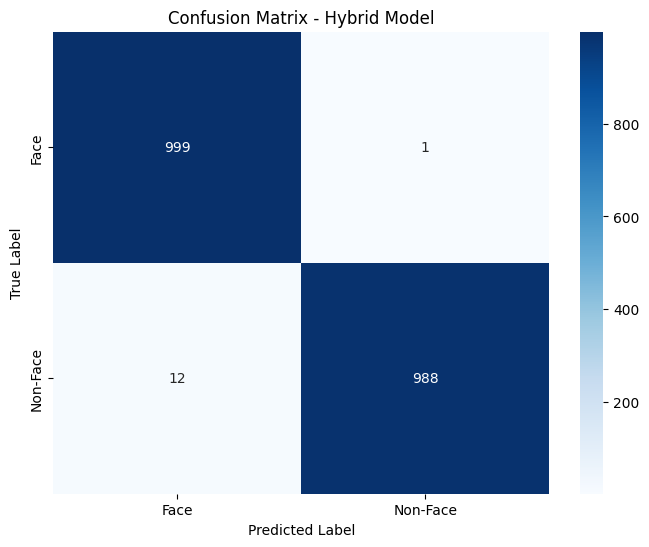

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Hybrid Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

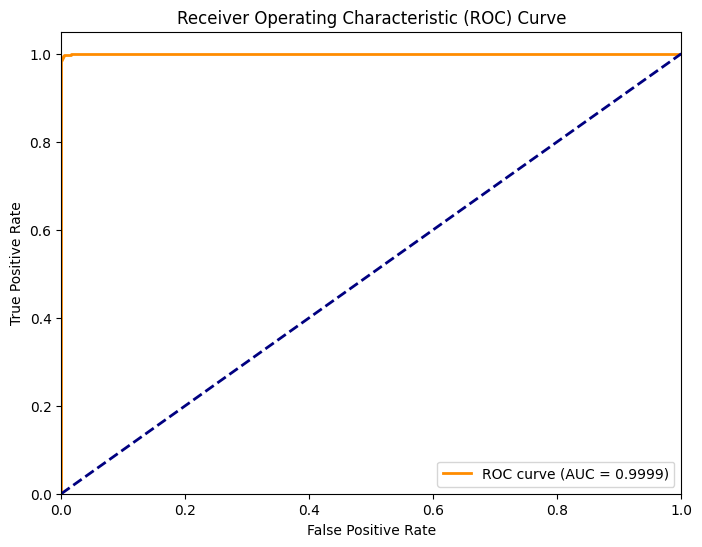

In [8]:
# ROC Curve (Assumes binary classification)
if len(class_names) == 2:
    fpr, tpr, thresholds = roc_curve(y_true_classes, y_pred_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
else:
    print("ROC Curve is configured for binary classification. You have", len(class_names), "classes.")

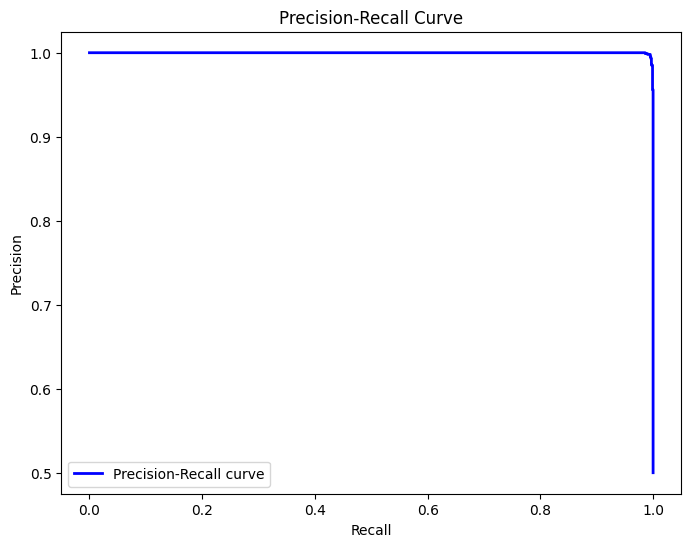

In [9]:
# Precision-Recall Curve (Assumes binary classification)
if len(class_names) == 2:
    precision_curve, recall_curve, _ = precision_recall_curve(y_true_classes, y_pred_probs[:, 1])

    plt.figure(figsize=(8, 6))
    plt.plot(recall_curve, precision_curve, color='blue', lw=2, label='Precision-Recall curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()
else:
    print("Precision-Recall Curve is configured for binary classification.")